Para abrir o notebook no Google Colab, altere o domínio `github.com` para `githubtocolab.com`

<div class="alert alert-block alert-danger">
Para praticar programação, é importante que você erre, leia as mensagens de erro e tente corrigí-los.
    
Dessa forma, no Google Colab, é importante que você DESATIVE OS RECURSOS DE AUTOCOMPLETAR:

- Menu Ferramentas -> Configurações
- Na janela que é aberta:
  - Seção Editor -> Desativar "Mostrar sugestões de preenchimento de código com base no contexto"
  - Seção Assistência de IA -> Desabilitar itens

Na versão em inglês:

- Menu Tools -> Settings
- Na janela que é aberta:
  - Seção Editor -> Desativar "Show context-powered code completions"
  - Seção AI Assistance -> Desabilitar itens
</div>

# Exercício 1 - Regressão Linear

Neste exercício, você vai construir um modelo usando a técnica de mínimos quadrados para estimar a concentração de monóxido de carbono (CO) a partir de medições de sensores ambientais, utilizando o conjunto de dados [`air_quality.csv`](./air_quality.csv). Esse banco de dados contém leituras horárias coletadas por sensores de qualidade do ar, incluindo variáveis associadas a diferentes poluentes (sensores e medições de gases) e também variáveis meteorológicas como temperatura (T), umidade relativa (RH) e umidade absoluta (AH).

Ao trabalhar com dados reais, muitas vezes é necessário realizar algumas etapas de filtragem e limpeza para usar os dados para construir um modelo. No caso desse banco de dados, há dois pontos importantes a levados tomados em consideração: (i) alguns valores de sensores aparecem como -200, o que representa alguma medição inválida e devem ser tratados como *missing value* e (ii) como o conjunto de dados consiste em uma série temporal, não deve ser utilizado nenhum tipo de embaralhamento, sendo necessário respeitar a ordem temporal.

No exercício, você irá carregar o dataset com o [Pandas](https://pandas.pydata.org/), tratar valores ausentes,construir um índice temporal juntando as colunas de data e hora, criando um objeto `DateTime` e criar variáveis de tempo (hora, dia e mês).

Após a instalação da biblioteca Pandas e o download do arquivo CSV, é possível carregar os dados com os seguintes comandos:

Obs.: *Caso esteja usando o Google Colab, é necessário fazer o upload do arquivo para o Colab, para que o `pd.read_csv` consiga carregar os dados.*

In [ ]:
import pandas as pd
air_data = pd.read_csv(
    "air_quality.csv",
    sep=",",
    decimal=".",
    na_values=["", " ", "NA", -200]
)
print("Colunas originais:", air_data.columns.tolist())

Colunas originais: ['Date', 'Time', 'CO', 'Poluente_1', 'Poluente_2', 'Poluente_3', 'Poluente_4', 'Poluente_5', 'Poluente_6', 'Poluente_7', 'Poluente_8', 'Poluente_9', 'T', 'RH', 'AH']


Com esses comandos, você vai criar um *DataFrame* do Pandas chamado `air_data` contendo os dados do arquivo CSV. A partir deste *DataFrame*, você pode gerar os *arrays* NumPy que serão usados para calcular os parâmetros do modelo de regressão linear.

Para ver algumas linhas do banco de dados, você pode usar o método `.head()`:

In [ ]:
air_data.head()

,Date,Time,CO,Poluente_1,Poluente_2,Poluente_3,Poluente_4,Poluente_5,Poluente_6,Poluente_7,Poluente_8,Poluente_9,T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


 A descrição dos dados é a seguinte:


| Coluna        | Descrição |
|---------------|------------|
| `Date`        | Data da medição no formato dia/mês/ano. |
| `Time`        | Horário da medição no formato hora:minuto:segundo. |
| `CO`          | Concentração de monóxido de carbono (variável alvo do modelo). |
| `Poluente_n`  | Medição de poluente atmosférico. |
| `T`           | Temperatura ambiente (°C). |
| `RH`          | Umidade relativa do ar (%). |
| `AH`          | Umidade absoluta do ar. |            |


No conjunto de dados, as informações temporais estão originalmente separadas nas colunas `Date` e `Time`. Para que o modelo possa explorar corretamente a estrutura temporal dos dados, é necessário realizar algumas etapas de processamento dessas colunas. Primeiramente, é interessante remover as linhas onde não existam dados e concatenar as colunas para convertê-las em um objeto no formato `datetime`:

In [ ]:
air_data = air_data.dropna(subset=["Date", "Time"])
air_data["DateTime"] = pd.to_datetime(
    air_data["Date"] + " " + air_data["Time"],
    format="%d/%m/%Y %H.%M.%S",
    )
air_data = air_data.dropna(subset=["DateTime"])

Em seguida, podemos configurar a nova coluna como sendo o índice do *DataFrame* e remover as colunas originais `Date` e `Time`:

In [ ]:
air_data = air_data.set_index("DateTime")
air_data = air_data.drop(columns=["Date", "Time"])

Finalmente, podemos criar novas variáveis derivadas a partir da coluna `DateTime`:

In [ ]:
air_data["Hora"] = air_data.index.hour
air_data["Dia"] = air_data.index.day
air_data["Mes"] = air_data.index.month

A proposta do exercício é que você construa um modelo de regressão linear para prever o valor da coluna do poluente `CO` (Monóxido de Carbono) a partir dos dados das demais variáveis. Para tanto, você pode gerar novas variáveis a partir das originais e/ou descartar variáveis caso julgue que não contribuam para o modelo.

Lembre-se que, para obter um modelo com desempenho melhor, você pode criar outras variáveis a partir de transformações e combinações das variáveis originais. Por exemplo, você poderia calcular a interação entre Temperatura e Umidade Relativa realizando uma multiplicação entre as duas colunas (`T`*`RH`), ou pode calcular a razão entre dois poluentes. Além disso, é possível realizar transformações mais complexas nas varíaveis, como a utilização de amostras passadas do poluente objetivo, visando um [modelo autorregressivo (AR)](https://otexts.com/fpp3/AR.html), ou utilizar métodos de suavização como é o caso da [média móvel (*moving average* - MA)](https://otexts.com/fpp3/moving-averages.html).

Essas variáveis devem ser incluídas como novas colunas no *DataFrame*. Seguem exemplos das sugestões citadas anteriormente:

```python
# 1) Uso de amostras passadas — AR
df["CO_lag1"] = df["CO"].shift(1)   # 1 hora atrás

# 2) Estatísticas móveis do CO
df["CO_media_movel_3h"] = df["CO"].rolling(window=3).mean()
df["CO_std_movel_3h"] = df["CO"].rolling(window=3).std()

# 3) Interações
df["Temp_x_UmidadeRelativa"] = df["T"] * df["RH"]

# Razão (Poluente_5 / Poluente_7)
df["Razao_P5_P7"] = df["Poluente_5"] / (df["Poluente_7"])

```

A base de dados deve ser dividida em um conjunto de treinamento (utilizado para treinar o modelo) e um conjunto de teste (utilizado para avaliar a capacidade de generalização do modelo). Utilize 70% dos dados para o treinamento e 30% para o teste. Para realizar essa divisão, podem ser utilizadas as seguintes linhas de código.

```python
tamanho_treino = int(0.7 * len(air_data))
X_treino, X_teste = X.iloc[:tamanho_treino], X.iloc[tamanho_treino:]
y_treino, y_teste = y.iloc[:tamanho_treino], y.iloc[tamanho_treino:]
```


Em resumo, para obter o vetor $\mathbf{w}_o$ com os coeficientes do modelo de regressão linear, você deve seguir os seguintes passos:

1. Selecionar as variáveis originais que você vai utilizar no modelo. Lembre-se que a variável `CO` não pode ser utilizada pois é a variável que você deseja prever com o modelo;

2. Transformar as variáveis originais de sua seleção e / ou incluir combinações, caso julgue necessário;

3. **Considerar apenas os dados de treinamento** e obter a matriz $\mathbf{X}$ e o vetor $\mathbf{d}$, que podem ser representados como *arrays* do NumPy. Para obter um *array* do NumPy a partir de um *DataFrame* do Pandas, você pode usar o método ``.to_numpy()``;

4. Usando a matriz $\mathbf{X}$ e o vetor $\mathbf{d}$, calcular o vetor $\mathbf{w}_o$ conforme mostrado na aula.

Após obter os coeficientes $\mathbf{w}_o$ do modelo de regressão linear, você vai utilizá-los para prever o valor estimado de CO usando o conjunto de dados de teste. Para cada linha do banco de dados de teste, calcule o valor predito pelo seu modelo e o erro em relação ao valor da coluna `CO`. Calcule também o erro quadrático médio considerando todo o banco de dados de teste.

Ao final do exercício, você deverá apresentar:

1. Uma descrição das variáveis de entrada que você utilizou como entrada e as justificativas para descartar variáveis ou utilizar transformações e combinações;

2. Os códigos utilizados para calcular o vetor $\mathbf{w}_o$ e o erro quadrático médio de seu modelo, considerando os dados de treinamento;

3. O valor obtido para o erro quadrático médio de seu modelo, considerando os dados de teste;

A sugestão é que seja apresentado um Jupyter Notebook usando a linguagem Python, já que essas são as ferramentas que estamos utilizando nesta parte do curso. No entanto, isso não é obrigatório e você pode usar outra linguagem de programação, caso queira.

## Instruções para entrega

- O exercício pode ser feito em dupla ou individualmente;

- A entrega deve incluir:
  - Um vídeo de no **máximo 40s**, mostrando a resolução do exercício;
  - Os **códigos-fontes** dos programas, preferencialmente organizados em um Jupyter Notebook, descrevendo o experimento e mostrando como foram obtidos os resultados solicitados.

- **A correção será feita baseada no vídeo**. Quando o professor/pesquisador ficar com alguma dúvida, serão consultados os códigos-fonte;

- Sobre o vídeo:
  - **Deve incluir áudio** descrevendo o experimento;
  - Gravem a tela do computador usando celular ou usando algum programa de captura de tela (por exemplo Zoom, Google Meet, ou OBS Studio);
  - No início, **deve aparecer o rosto e algum documento do aluno que gravou o vídeo** (como a carteira USP, RG, CNH, etc);
  - No caso de entrega em dupla, **não é necessário que os dois componentes apareçam no vídeo**. No entanto, alternem o apresentador ao longo das entregas dos exercícios e **não esqueçam de incluir os dois nomes no início do vídeo**.
  - Procurem convencer o espectador do vídeo, que vai corrigir o exercício que fizeram os exercícios computacionais solicitados e que eles estão funcionando corretamente. Tentem fazer um bom aproveitamento do tempo para apresentar os resultados solicitados, **respeitando o limite de 40s e não acelerem a velocidade do vídeo**;

- Sobre os códigos-fonte:
  - **Incluir o nome do(s) aluno(s)** no início do programa;

- Sobre o envio no Moodle:
  - Apenas um aluno de cada dupla deve enviar o vídeo no Moodle;
  - Podem ser enviados o arquivo de vídeo (.mkv, .mp4, .avi, etc.) ou um link para o vídeo (Youtube, Google Drive, etc);
    - No segundo caso, certifiquem-se que todos os professores/pesquisadores (magno.silva@usp.br, hae.kim@usp.br, sergiocaceres01@usp.br, renatocan@lps.usp.br) tenham acesso ao seu vídeo.
  - Não se esqueçam de escrever o nome dos componentes da dupla (ou do único aluno, escrevendo: "exercício feito individualmente") em três lugares diferentes: **no campo "comentários sobre o envio" no Moodle**, **no início do vídeo** e no **início dos códigos-fonte**.




# Exercício 1 - Regressão Linear
## Nome: Gabriel Cordeiro Caram
#### Exercício feito individualmente

# PASSO 1: Carregamento e Limpeza Básica

In [ ]:
import pandas as pd
import numpy as np

air_data = pd.read_csv("air_quality.csv", sep=",", decimal=".", na_values=["", " ", "NA", -200])
air_data = air_data.dropna(subset=["Date", "Time"])
air_data["DateTime"] = pd.to_datetime(air_data["Date"] + " " + air_data["Time"], format="%d/%m/%Y %H.%M.%S")
air_data = air_data.dropna(subset=["DateTime"])
air_data = air_data.set_index("DateTime")
air_data = air_data.drop(columns=["Date", "Time"])
air_data["Hora"] = air_data.index.hour
air_data["Dia"] = air_data.index.day
air_data["Mes"] = air_data.index.month

In [ ]:
air_data.head(5)

,CO,Poluente_1,Poluente_2,Poluente_3,Poluente_4,Poluente_5,Poluente_6,Poluente_7,Poluente_8,Poluente_9,T,RH,AH,Hora,Dia,Mes
DateTime,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,18,10,3
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,19,10,3
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,20,10,3
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,21,10,3
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,22,10,3


# PASSO 2: Criação de novas variáveis de interesse

#### Para melhorar o acerto do modelo, podemos adicionar variáveis que assistam a previsão. Por exemplo, criar uma coluna que faça o modelo acessar os valores anteriores de CO, para que ele também tenha um histórico para prever o próximo valor. Para isso, podemos fazer uma função de autocorrelação e correlação parcial para verificar os lags mais predominantes, garantindo que seja coberta sazonalidade também.

#### Também podemos criar uma coluna que indique para o modelo um classificador de horários em que é sabido que há mais poluição, como horários de pico de carros e dias da semana. Também podemos alterar o horário para uma função senoide, de forma a deixar cíclico e facilitar para o modelo.

#### Por fim, fisicamente, sabe-se que a inversão térmica é um fenômeno que afeta a concentração de poluentes na atmosfera. Essa inversão pode ser caracterizada pela média móvel da temperatura nas últimas horas e de alguns poluentes nitrificados (NOx). Para abordar esses atributos na análise, faremos a média móvel de 4 horas de cada poluente e da temperatura e adicionaremos à tabela.

In [ ]:
air_data['CO']

,CO
DateTime,
2004-03-10 18:00:00,2.6
2004-03-10 19:00:00,2.0
2004-03-10 20:00:00,2.2
2004-03-10 21:00:00,2.2
2004-03-10 22:00:00,1.6
...,...
2005-04-04 10:00:00,3.1
2005-04-04 11:00:00,2.4
2005-04-04 12:00:00,2.4


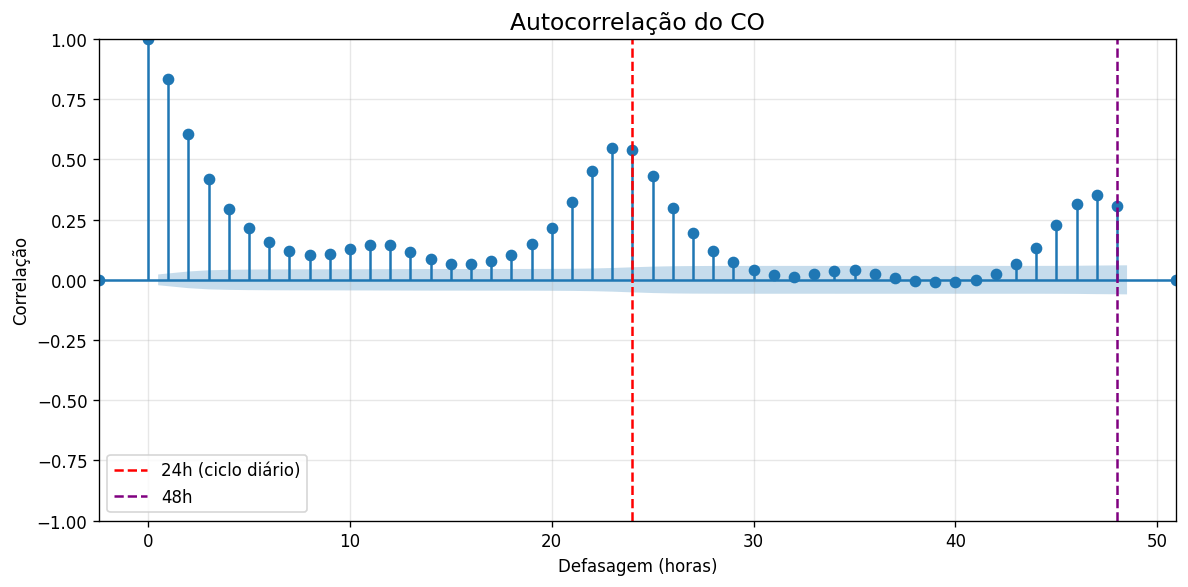

In [ ]:
# função de autocorrelação e autocorrelação parcial de CO
co_na = air_data['CO'].dropna()
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10,5), dpi=120)

plot_acf(
    co_na,
    lags=48,
    ax=ax,
    alpha=0.05,
    marker='o',
    markersize=6
)

# destacar lags importantes
ax.axvline(24, color='red', linestyle='--', linewidth=1.5, label='24h (ciclo diário)')
ax.axvline(48, color='purple', linestyle='--', linewidth=1.5, label='48h')

ax.set_title("Autocorrelação do CO", fontsize=14)
ax.set_xlabel("Defasagem (horas)")
ax.set_ylabel("Correlação")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

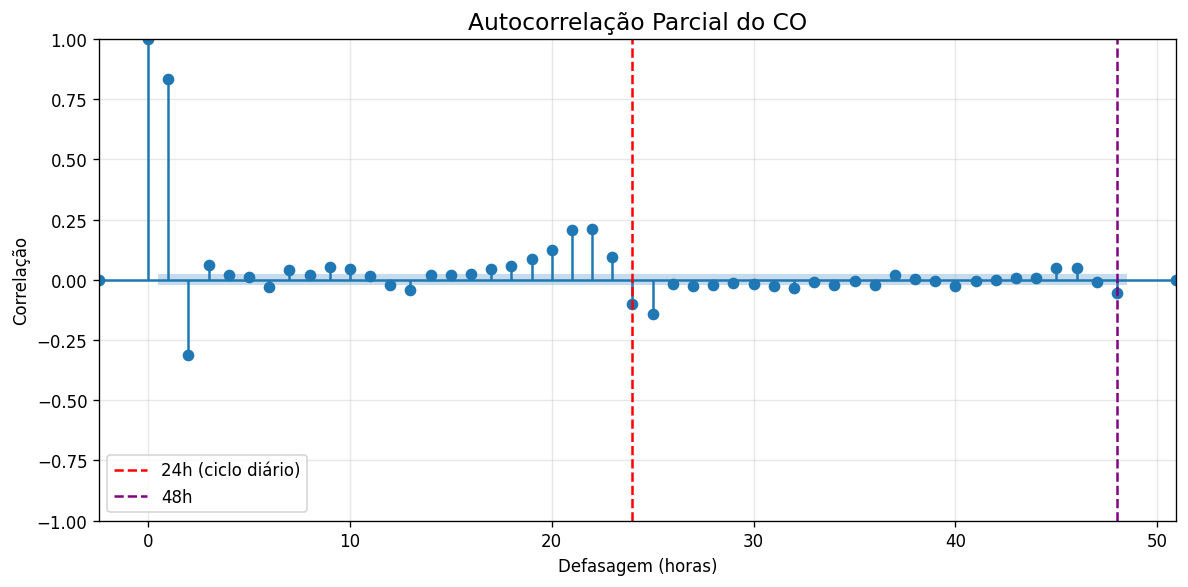

In [ ]:
# função de autocorrelação e autocorrelação parcial de CO

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(10,5), dpi=120)

plot_pacf(
    co_na,
    lags=48,
    ax=ax,
    alpha=0.05,
    marker='o',
    markersize=6
)

# destacar lags importantes
ax.axvline(24, color='red', linestyle='--', linewidth=1.5, label='24h (ciclo diário)')
ax.axvline(48, color='purple', linestyle='--', linewidth=1.5, label='48h')

ax.set_title("Autocorrelação Parcial do CO", fontsize=14)
ax.set_xlabel("Defasagem (horas)")
ax.set_ylabel("Correlação")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Pelos gráficos, pode-se concluir que os lags mais importantes são lag 1, lag 2 e lag 24, para dar ao modelo o histórico das últimas duas horas e também do dia passado, contribuindo para a sazonalidade.

In [ ]:
air_data["CO_lag1"] = air_data["CO"].shift(1)
air_data["CO_lag2"] = air_data["CO"].shift(2)
air_data["CO_lag24"] = air_data["CO"].shift(24)

In [ ]:
# classificador de horários

# Transforma a hora (0-23) em coordenadas de um círculo
air_data["Hora_sin"] = np.sin(2 * np.pi * air_data["Hora"] / 24)
air_data["Hora_cos"] = np.cos(2 * np.pi * air_data["Hora"] / 24)

air_data["Horario_Pico"] = air_data["Hora"].apply(lambda x: 1 if x in [7, 8, 9, 17, 18, 19] else 0)

air_data["Fim_de_Semana"] = air_data.index.dayofweek.map(lambda x: 1 if x >= 5 else 0)

Agora gerando as médias móveis

In [ ]:

colunas_poluentes = [f"Poluente_{i}" for i in range(1, 10)]

for col in colunas_poluentes:
    air_data[f"{col}_Media_4h"] = air_data[col].rolling(window=4).mean()

air_data["T_Media_4h"] = air_data["T"].rolling(window=4).mean()
air_data["AH_Media_4h"] = air_data["AH"].rolling(window=4).mean()

air_data["CO_lag1"] = air_data["CO"].shift(1)

air_data = air_data.dropna()

In [ ]:
print(list(air_data.columns))

['CO', 'Poluente_1', 'Poluente_2', 'Poluente_3', 'Poluente_4', 'Poluente_5', 'Poluente_6', 'Poluente_7', 'Poluente_8', 'Poluente_9', 'T', 'RH', 'AH', 'Hora', 'Dia', 'Mes', 'CO_lag1', 'CO_lag2', 'CO_lag24', 'Hora_sin', 'Hora_cos', 'Horario_Pico', 'Fim_de_Semana', 'Poluente_1_Media_4h', 'Poluente_2_Media_4h', 'Poluente_3_Media_4h', 'Poluente_4_Media_4h', 'Poluente_5_Media_4h', 'Poluente_6_Media_4h', 'Poluente_7_Media_4h', 'Poluente_8_Media_4h', 'Poluente_9_Media_4h', 'T_Media_4h', 'AH_Media_4h']


# PASSO 3: Separação entre Variáveis de Entrada (X) e Alvo (y) e divisão entre treino e teste

In [ ]:
y = air_data["CO"]
X = air_data.drop(columns=["CO"])
tamanho_treino = int(0.7 * len(air_data))
X_treino, X_teste = X.iloc[:tamanho_treino], X.iloc[tamanho_treino:]
y_treino, y_teste = y.iloc[:tamanho_treino], y.iloc[tamanho_treino:]

 # PASSO 4: Análise de Correlação

In [ ]:
df_analise_treino = X_treino.copy()
df_analise_treino["CO"] = y_treino

# matriz de correlação de Pearson
matriz_correlacao = df_analise_treino.corr()

# apenas a coluna de correlação com CO
correlacao_com_alvo = matriz_correlacao["CO"].sort_values(key=abs, ascending=False)

print("Correlação das variáveis com o CO no conjunto de treinamento:")
print(correlacao_com_alvo)


Correlação das variáveis com o CO no conjunto de treinamento:
CO                     1.000000
Poluente_3             0.977943
Poluente_4             0.961045
Poluente_5             0.956763
Poluente_8             0.948586
Poluente_1             0.933007
Poluente_9             0.876382
Poluente_7             0.861692
Poluente_6            -0.833549
Poluente_2             0.832755
CO_lag1                0.733394
Poluente_3_Media_4h    0.697788
Poluente_5_Media_4h    0.692382
Poluente_8_Media_4h    0.685450
Poluente_1_Media_4h    0.674244
Poluente_4_Media_4h    0.672590
Poluente_9_Media_4h    0.588085
CO_lag24               0.563889
Poluente_7_Media_4h    0.544168
Poluente_6_Media_4h   -0.516581
Poluente_2_Media_4h    0.513645
CO_lag2                0.361538
Horario_Pico           0.296984
Hora                   0.249759
AH                     0.246253
T                      0.208382
T_Media_4h             0.204505
Fim_de_Semana         -0.175865
Hora_cos              -0.171169
AH_Media_4

Provavelmente a grande correlação de todos os poluentes com o CO indica que todos eles são lançados à atmosfera em conjunto, com exceção do poluente 6. Sendo assim, talvez isso seja um caso de multicolinearidade no modelo. Dessa forma, basta selecionar apenas um dos vários poluentes de forma a evitar inserir informações redundantes. Vamos verificar se esse é de fato o caso para os poluentes mais correlatos com CO.

Matriz de correlação cruzada entre os poluentes:
            Poluente_1  Poluente_3  Poluente_4  Poluente_5  Poluente_8  \
Poluente_1    1.000000    0.929859    0.932086    0.928129    0.950177   
Poluente_3    0.929859    1.000000    0.985739    0.938968    0.964371   
Poluente_4    0.932086    0.985739    1.000000    0.933251    0.962276   
Poluente_5    0.928129    0.938968    0.933251    1.000000    0.930950   
Poluente_8    0.950177    0.964371    0.962276    0.930950    1.000000   
Poluente_9    0.944684    0.884004    0.894402    0.895347    0.908683   

            Poluente_9  
Poluente_1    0.944684  
Poluente_3    0.884004  
Poluente_4    0.894402  
Poluente_5    0.895347  
Poluente_8    0.908683  
Poluente_9    1.000000  


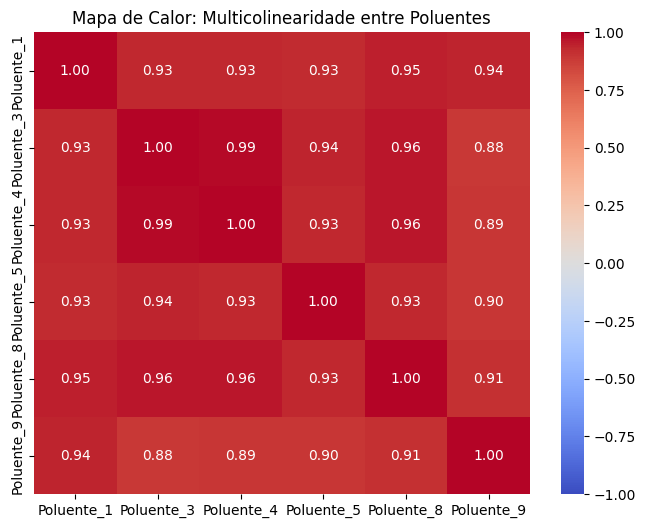

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pegamos apenas os poluentes que tiveram correlação gigante com o CO
poluentes_suspeitos = [
    "Poluente_1", "Poluente_3", "Poluente_4",
    "Poluente_5", "Poluente_8", "Poluente_9"
]

# 2. Calculamos a correlação DELES ENTRE SI
matriz_poluentes = X_treino[poluentes_suspeitos].corr()

# 3. Exibimos a tabela numérica
print("Matriz de correlação cruzada entre os poluentes:")
print(matriz_poluentes)

# 4. Geramos o Mapa de Calor para ficar fácil de ver na tela
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_poluentes, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Mapa de Calor: Multicolinearidade entre Poluentes")
plt.show()

De fato, a maioria dos poluentes já possui 90% de correlação entre si, então pode-se simplificar o modelo ao utilizar apenas o mais correlato com CO: o poluente 3.

Além disso, o coeficiente de Pearson não consegue medir bem a correlação entre uma variável contínua e variáveis cíclicas. Logo, também serão mantidas as colunas de horário senoidais. Sendo assim, as colunas mantidas estão descritas abaixo.

In [ ]:
features_selecionadas = [
    "Poluente_3",
    "Poluente_6",
    "CO_lag1",
    "CO_lag24",
    "Hora_sin",
    "Hora_cos"
]

X = air_data[features_selecionadas]
y = air_data["CO"]
tamanho_treino = int(0.7 * len(air_data))
X_treino, X_teste = X.iloc[:tamanho_treino], X.iloc[tamanho_treino:]
y_treino, y_teste = y.iloc[:tamanho_treino], y.iloc[tamanho_treino:]

In [ ]:
X_treino

,Poluente_3,Poluente_6,CO_lag1,CO_lag24,Hora_sin,Hora_cos
DateTime,,,,,,
2004-03-11 18:00:00,20.8,799.0,2.9,2.6,-1.000000e+00,-1.836970e-16
2004-03-11 19:00:00,27.4,702.0,4.8,2.0,-9.659258e-01,2.588190e-01
2004-03-11 20:00:00,24.0,743.0,6.9,2.2,-8.660254e-01,5.000000e-01
2004-03-11 21:00:00,12.8,957.0,6.1,2.2,-7.071068e-01,7.071068e-01
2004-03-11 22:00:00,4.7,1325.0,3.9,1.6,-5.000000e-01,8.660254e-01
...,...,...,...,...,...,...
2004-04-12 11:00:00,3.9,1105.0,1.0,1.8,2.588190e-01,-9.659258e-01
2004-04-12 12:00:00,2.8,1201.0,1.3,2.6,1.224647e-16,-1.000000e+00
2004-04-12 13:00:00,1.4,1415.0,1.1,1.1,-2.588190e-01,-9.659258e-01


In [ ]:
y_treino

,CO
DateTime,
2004-03-11 18:00:00,4.8
2004-03-11 19:00:00,6.9
2004-03-11 20:00:00,6.1
2004-03-11 21:00:00,3.9
2004-03-11 22:00:00,1.5
...,...
2004-04-12 11:00:00,1.3
2004-04-12 12:00:00,1.1
2004-04-12 13:00:00,0.6


# Passo 5: Preparação para regressão

In [ ]:
import numpy as np

# converter para numpy
X_treino_np = X_treino.to_numpy()
y_treino_np = y_treino.to_numpy()

X_teste_np = X_teste.to_numpy()
y_teste_np = y_teste.to_numpy()

# vetores com coluna 1
uns_treino = np.ones((X_treino_np.shape[0], 1))
uns_teste = np.ones((X_teste_np.shape[0], 1))

# adicionando viés
X_treino_bias = np.c_[uns_treino, X_treino_np]
X_teste_bias = np.c_[uns_teste, X_teste_np]


# Passo 6: Cálculo do vetor de pesos

In [ ]:
X_matriz = X_treino_bias
d_vetor = y_treino_np

# equação de regressão
A = X_matriz.T @ X_matriz
b = X_matriz.T @ d_vetor
w_o = np.linalg.solve(A, b)

print("Vetor de pesos encontrado (w_o):")
print(np.round(w_o, 4))

Vetor de pesos encontrado (w_o):
[-0.0876  0.1847  0.0003  0.0913 -0.0009  0.0057  0.0575]


# PASSO 7: Previsões no Conjunto de Teste e Avaliação de Desempenho

In [ ]:
print("--- Desempenho do Modelo no Conjunto de Teste ---")
print(f"MSE  (Erro Quadrático Médio):       {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático):     {rmse:.4f}")
print(f"MAE  (Erro Absoluto Médio):         {mae:.4f}")
print("-" * 50)


--- Desempenho do Modelo no Conjunto de Teste ---
MSE  (Erro Quadrático Médio):       0.1518
RMSE (Raiz do Erro Quadrático):     0.3896
MAE  (Erro Absoluto Médio):         0.2978
--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# previsões
y_pred = X_teste_bias @ w_o

# métricas de erro
mse = np.mean((y_teste_np - y_pred) ** 2)

rmse = np.sqrt(mse)

mae = np.mean(np.abs(y_teste_np - y_pred))

print("--- Desempenho do Modelo no Conjunto de Teste ---")
print(f"MSE  (Erro Quadrático Médio):       {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático):     {rmse:.4f}")
print(f"MAE  (Erro Absoluto Médio):         {mae:.4f}")
print("-" * 50)

# real vs previsto
plt.figure(figsize=(8, 8))
plt.scatter(y_teste_np, y_pred, alpha=0.4, color='teal', edgecolor='k')

min_val = min(y_teste_np.min(), y_pred.min())
max_val = max(y_teste_np.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Previsão Perfeita')

plt.title("Desempenho Geral: CO Real vs. CO Previsto", fontsize=14)
plt.xlabel("Valores Reais de CO", fontsize=12)
plt.ylabel("Valores Previstos pelo Modelo", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

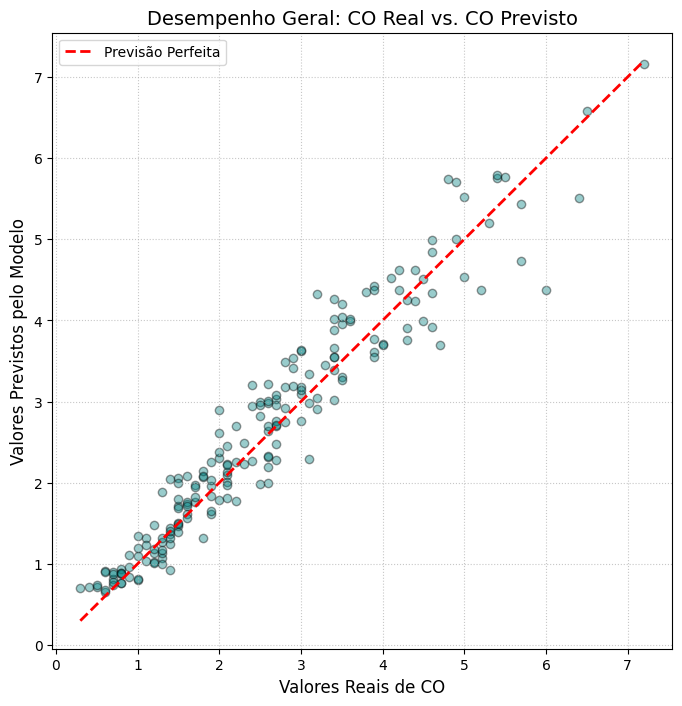

In [ ]:
# série temporal
fatia = 135

plt.figure(figsize=(15, 5))
plt.plot(y_teste_np[:fatia], label="CO Real (Observado)", color='black', linewidth=2, marker='.')
plt.plot(y_pred[:fatia], label="CO Previsto (Modelo)", color='darkorange', linewidth=2, linestyle='--', marker='x')

plt.title(f"Acompanhamento Temporal: Real vs Previsto (Primeiras {fatia} horas do Teste)", fontsize=14)
plt.xlabel("Horas (Tempo)", fontsize=12)
plt.ylabel("Concentração de CO", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

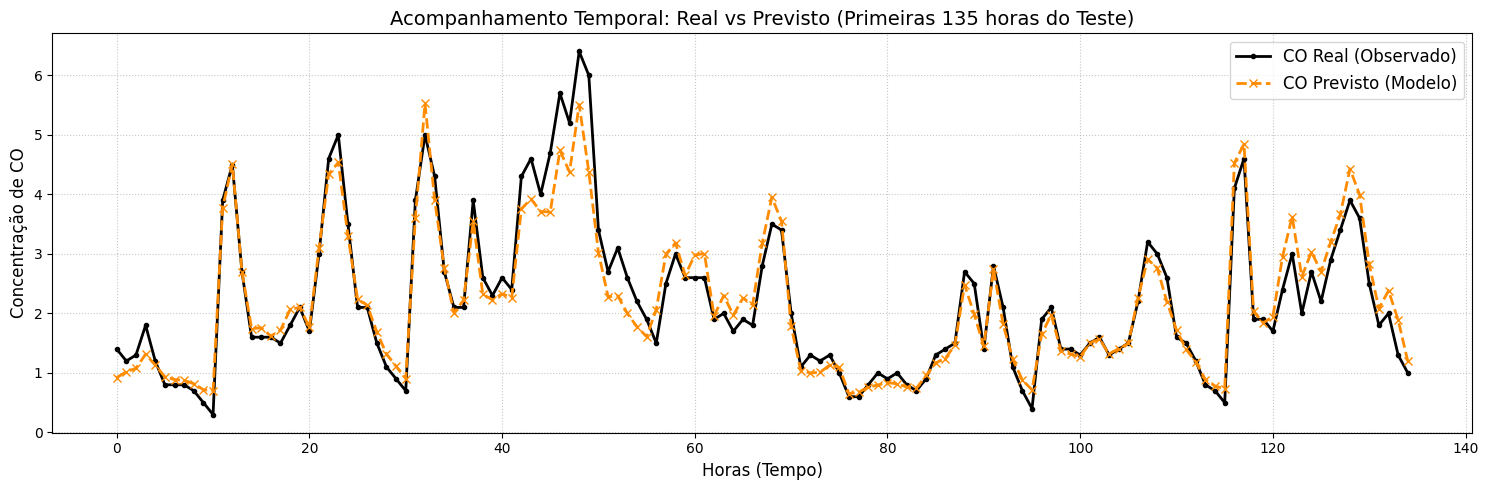

# Passo 8: Conclusão



#### Este projeto mostrou que é possível construir um modelo de Regressão Linear do zero usando operações matriciais para prever os níveis de monóxido de carbono (CO). Os bons resultados obtidos (MAE de ~0,29) indicam que a qualidade da preparação dos dados tem um papel fundamental no desempenho do modelo.

#### Com algumas transformações simples nos dados e a escolha cuidadosa das variáveis mais relevantes, foi possível obter previsões bastante precisas. Isso reforça que modelos clássicos, quando bem aplicados, ainda são ferramentas eficazes para análise e previsão de dados ambientais.